
## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


## 2. Load Dataset

In [4]:
train = pd.read_csv("train.csv")
valid = pd.read_csv("valid.csv")

## 3. Data Preprocessing

In [5]:
y_train = train["label"].values
X_train = train.drop("label", axis=1).values / 255.0

y_valid = valid["label"].values
X_valid = valid.drop("label", axis=1).values / 255.0

In [ ]:
# reshape to (28,28,1)
X_train = X_train.reshape(-1,28,28,1)
X_valid = X_valid.reshape(-1,28,28,1)


## 4. Data Augmentation

In [7]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10
)

train_generator = datagen.flow(X_train, y_train, batch_size=64)

## 5. Build CNN Model

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(24, activation='softmax')  # 24 ASL classes
])

c:\Users\Farma\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Compiling

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Training

In [ ]:
history = model.fit(
    train_generator,
    validation_data=(X_valid, y_valid),
    epochs=5
)
# Save model
model.save("asl_cnn_model.keras")

Epoch 1/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 1.0000 - loss: 2.5892e-04 - val_accuracy: 0.9545 - val_loss: 0.2933
Epoch 2/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9497 - val_loss: 0.2602
Epoch 3/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9986 - loss: 0.0042 - val_accuracy: 0.9421 - val_loss: 0.3100
Epoch 4/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9970 - loss: 0.0094 - val_accuracy: 0.9608 - val_loss: 0.2798
Epoch 5/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 1.0000 - loss: 3.8634e-04 - val_accuracy: 0.9664 - val_loss: 0.2768


## 8. Evaluation

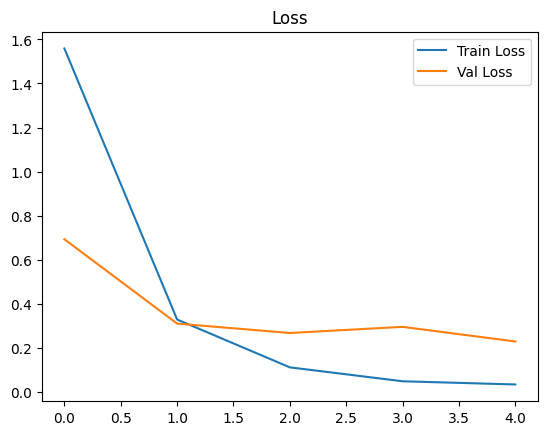

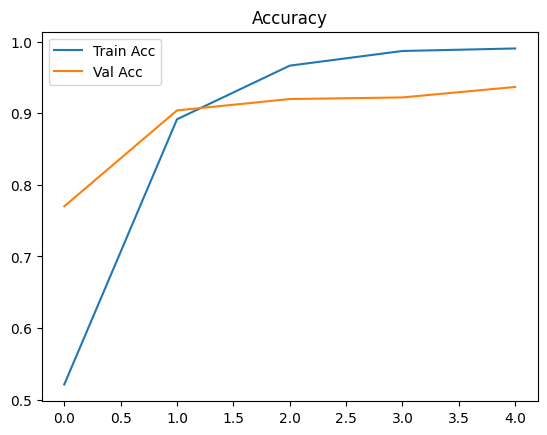

In [11]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

## Conclusion

In this project, we built a CNN to classify ASL hand signs using a preprocessed dataset. 
The model achieved good accuracy and demonstrates the effectiveness of convolutional networks for image classification tasks.